<h2 style="font-size: 40px;">1. BNB</h2>

<h2 style="font-size: 24px;">1.1. yy-shower reco selection</h2>

 true_photon_multiplicity  true_muon_multiplicity  true_pion_multiplicity  true_proton_multiplicity  true_electron_multiplicity  count
                      2.0                     0.0                     0.0                       1.0                         0.0     53
                      2.0                     0.0                     1.0                       0.0                         0.0     29
                      1.0                     0.0                     0.0                       0.0                         0.0     26
                      0.0                     0.0                     1.0                       0.0                         0.0      8
                      0.0                     1.0                     1.0                       0.0                         0.0      7
                      2.0                     1.0                     0.0                       0.0                         0.0      4
                      0.0                     0.0      

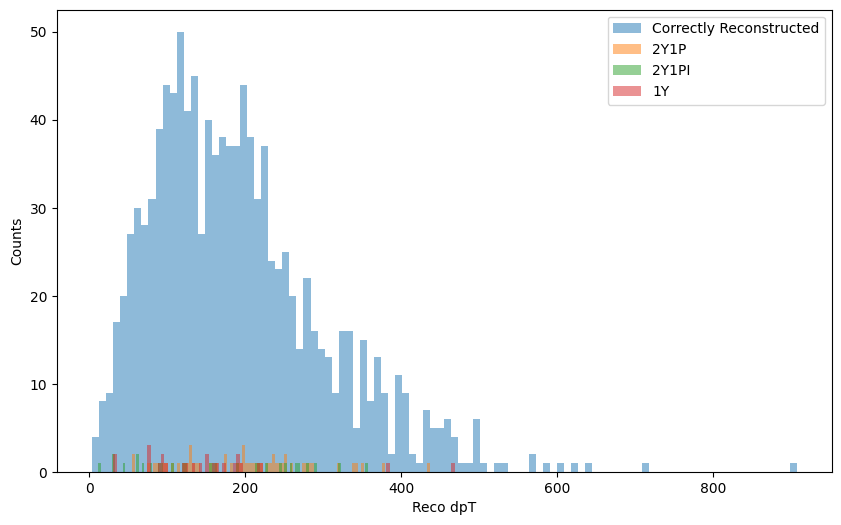

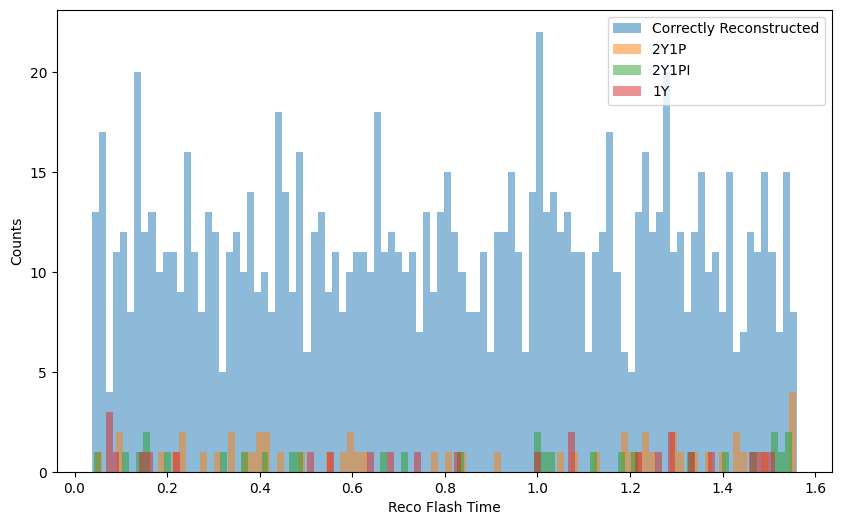

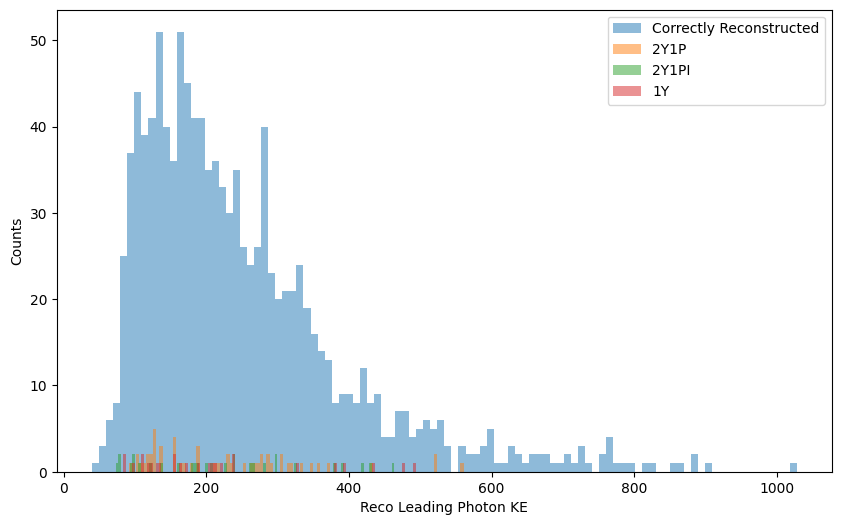

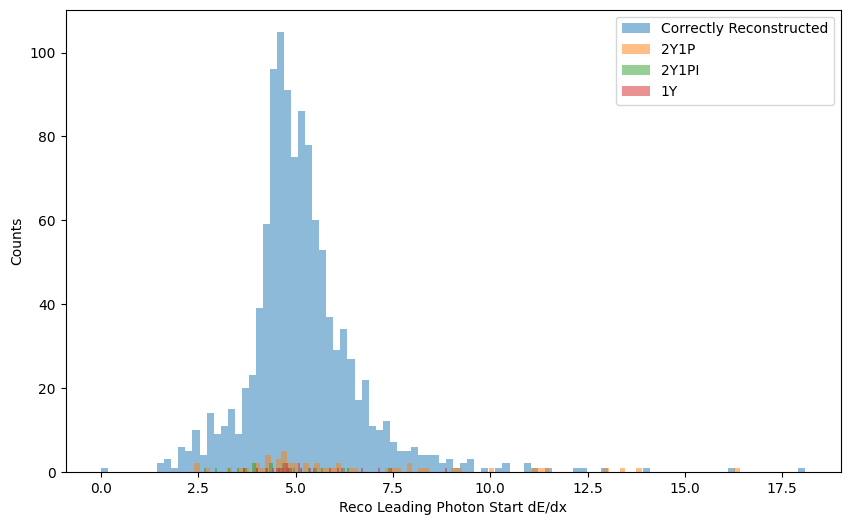

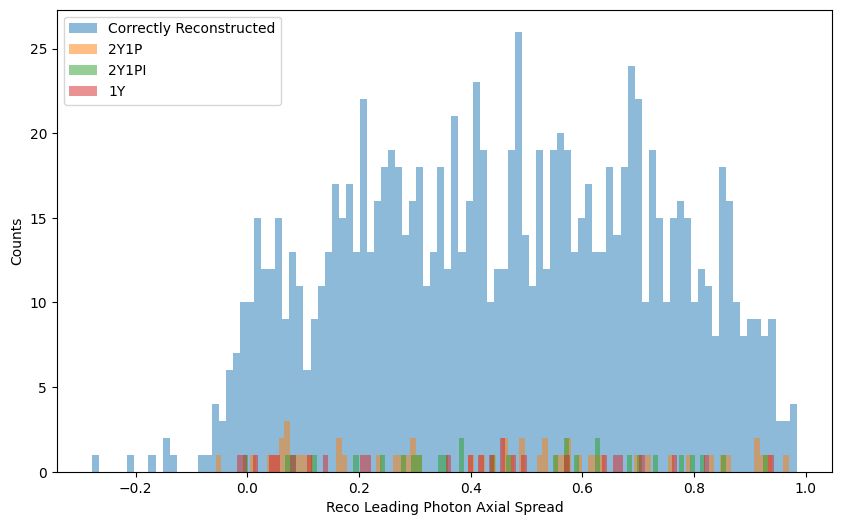

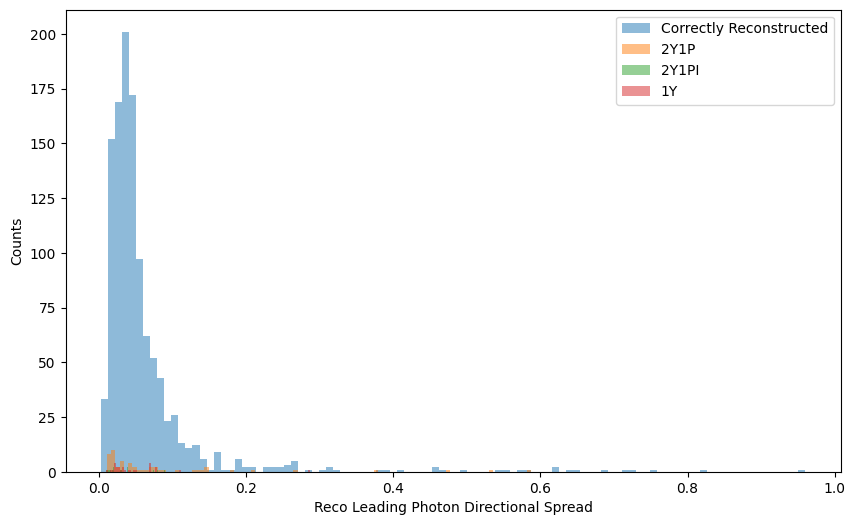

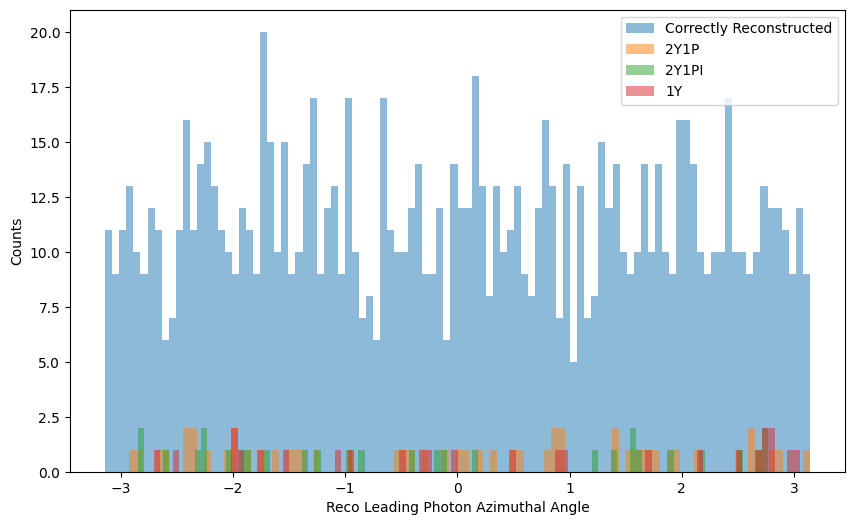

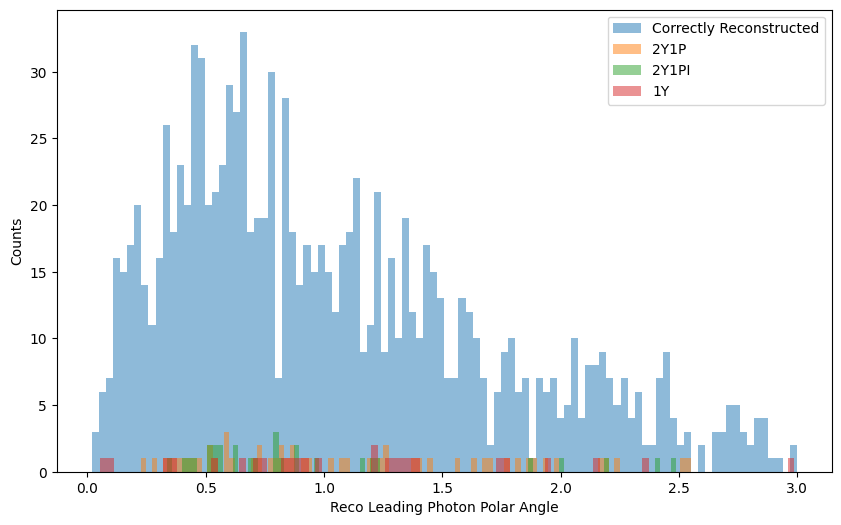

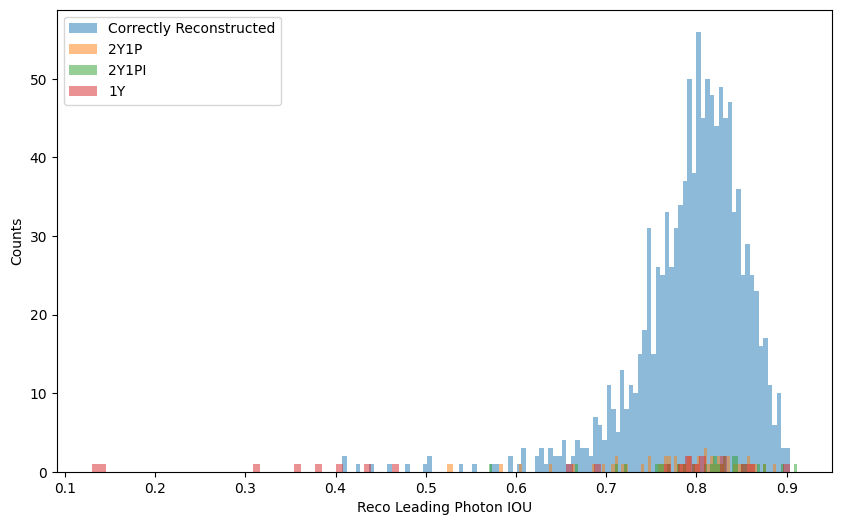

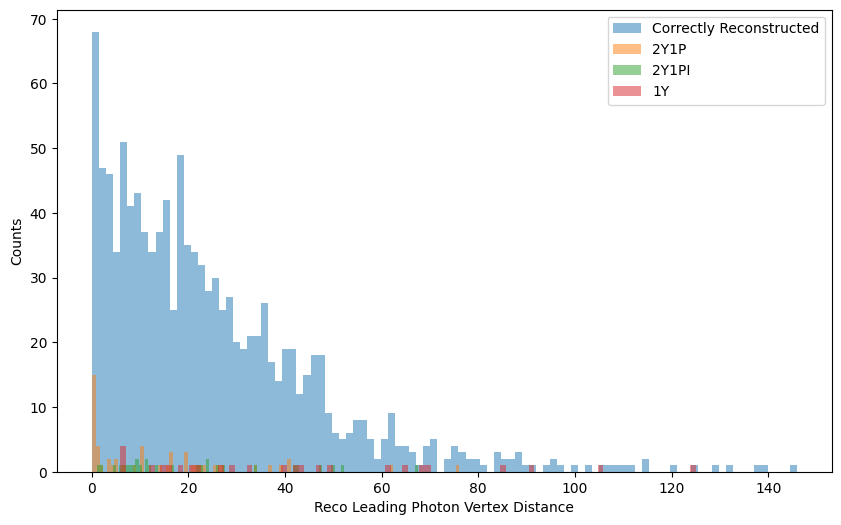

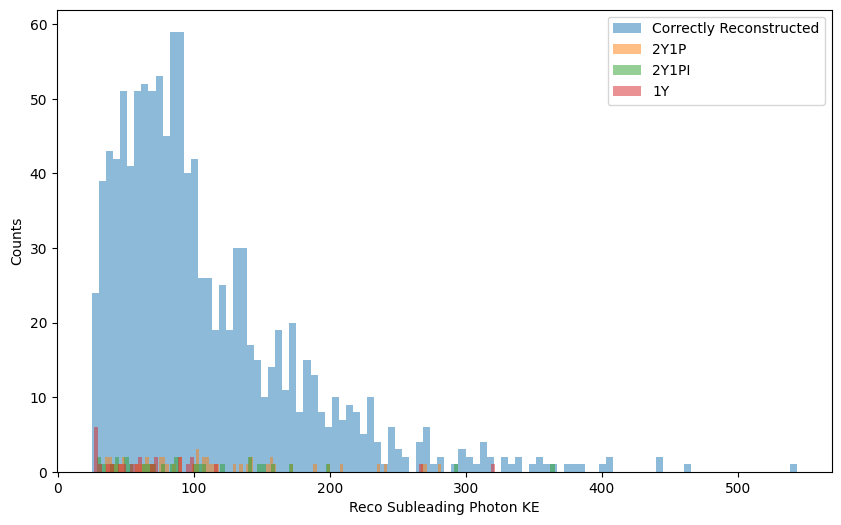

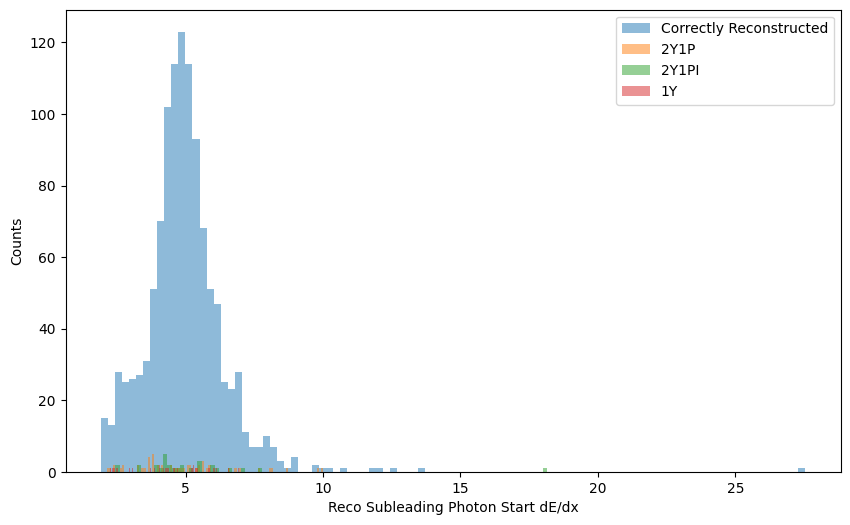

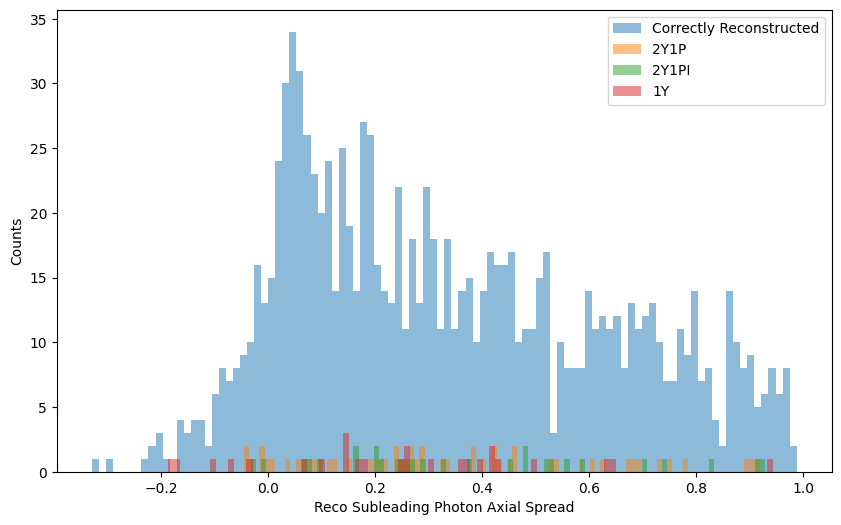

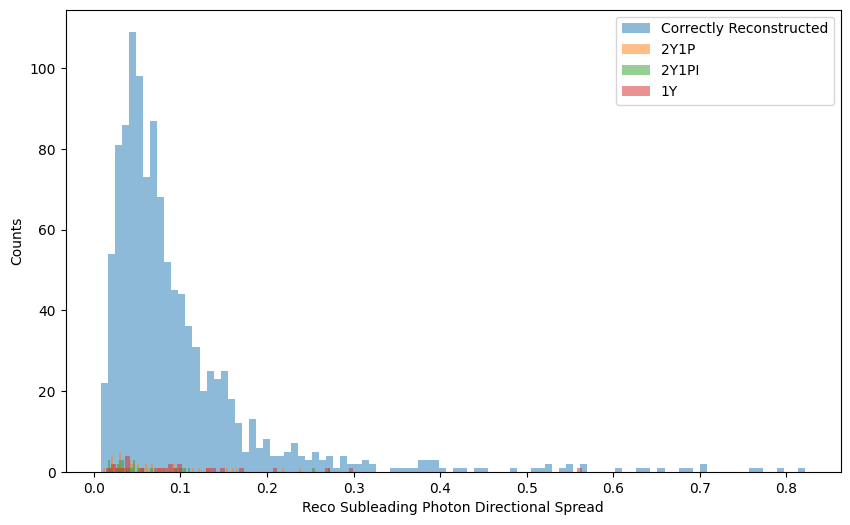

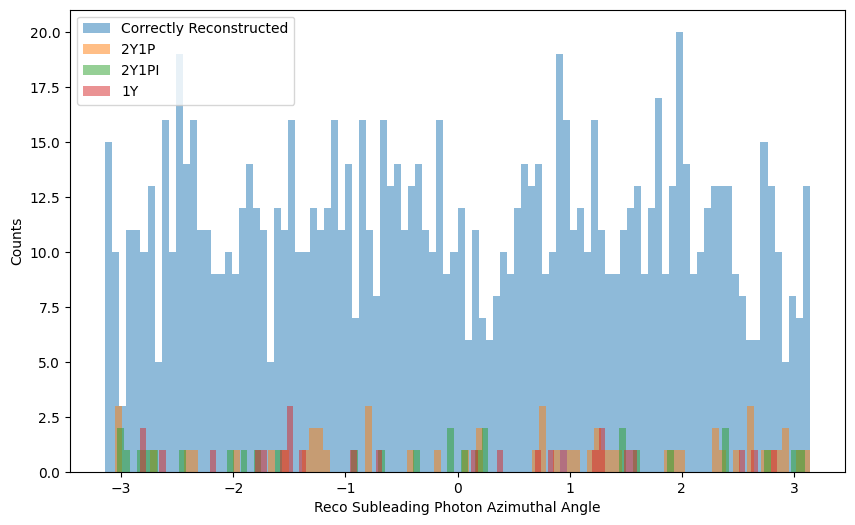

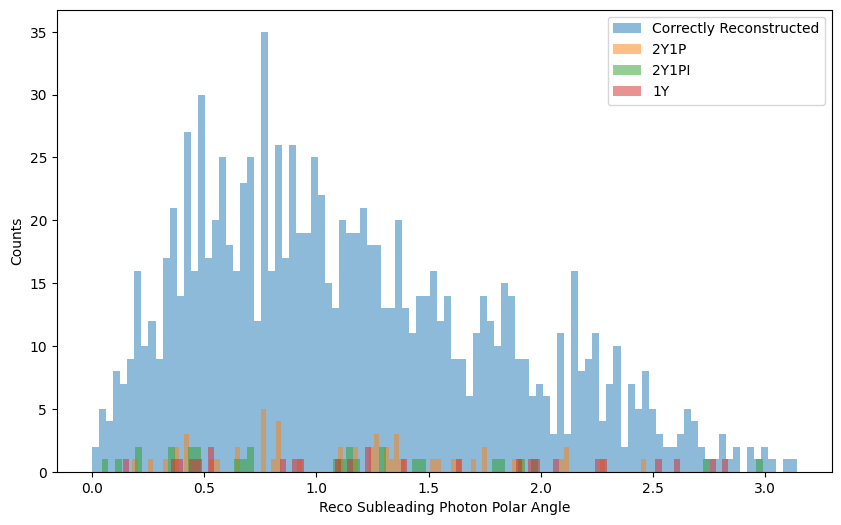

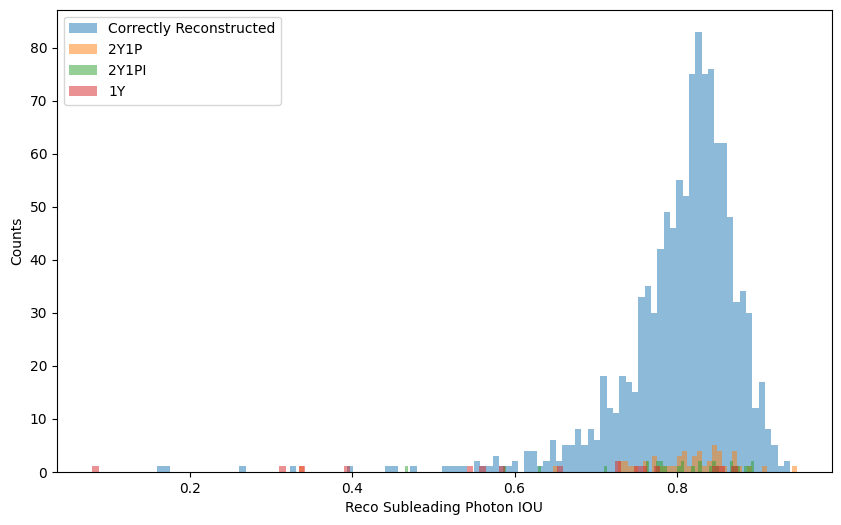

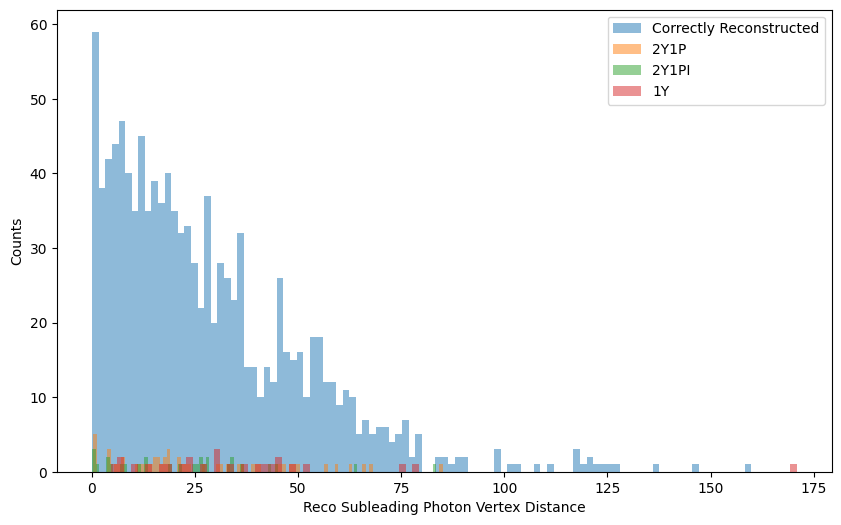

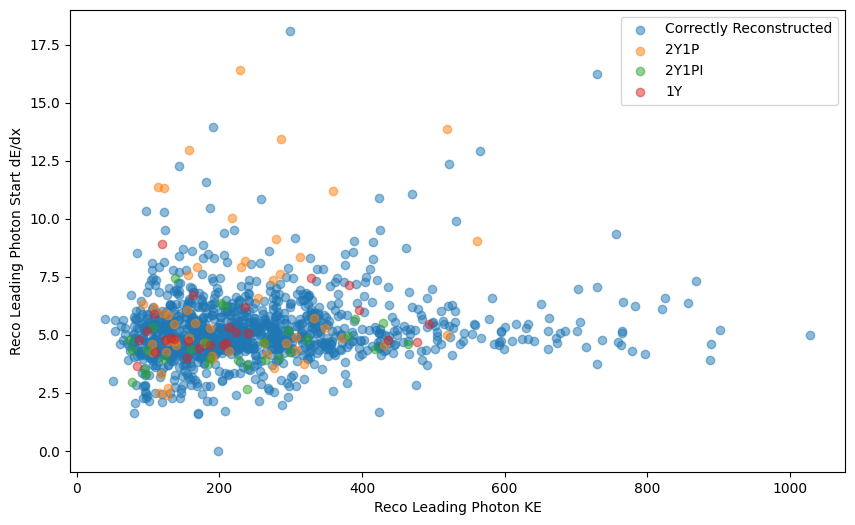

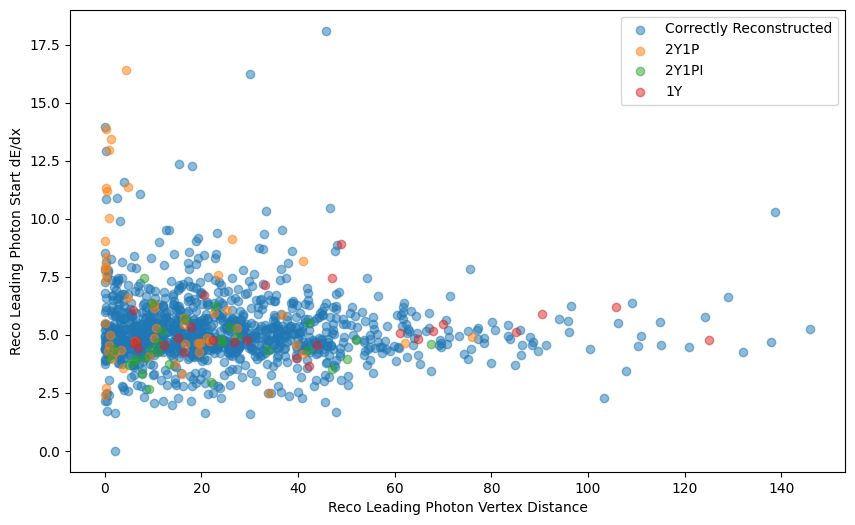

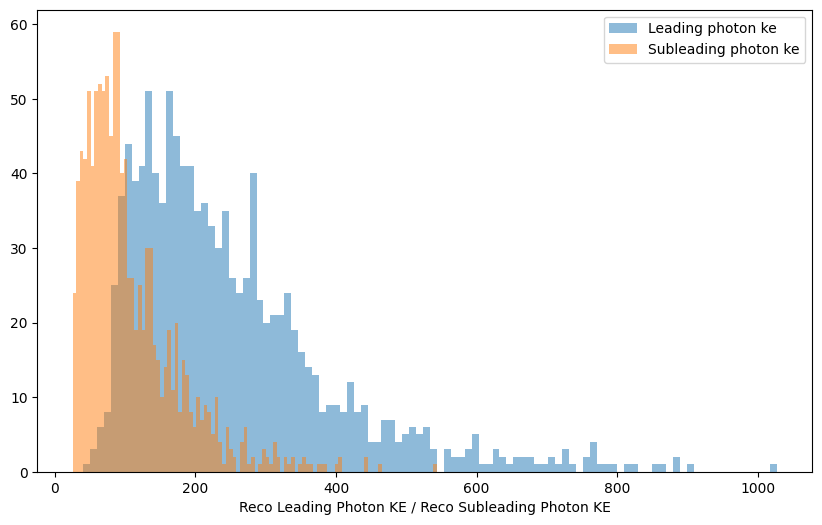

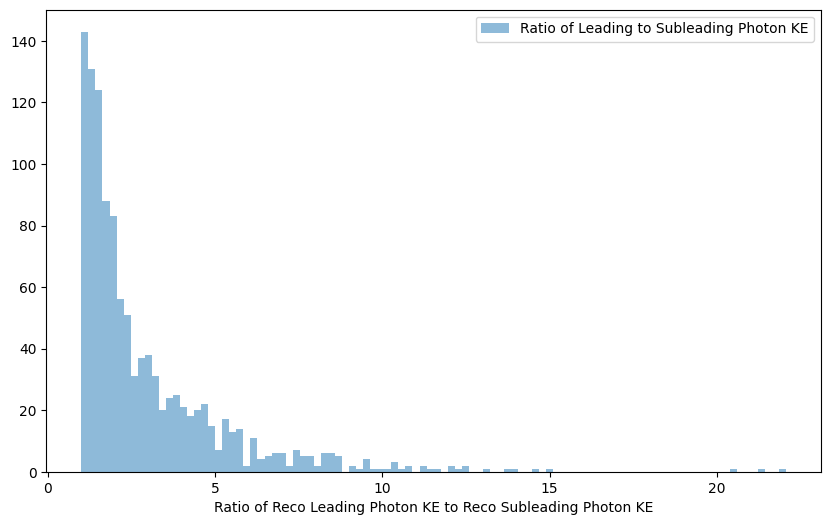

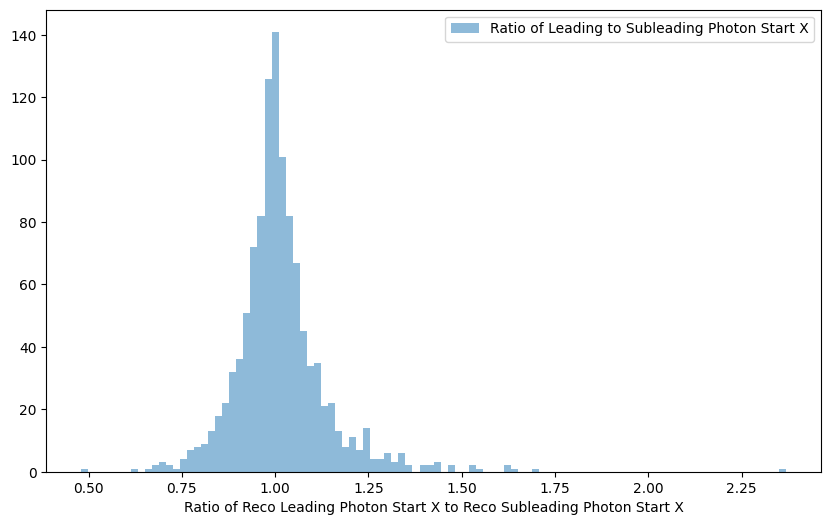

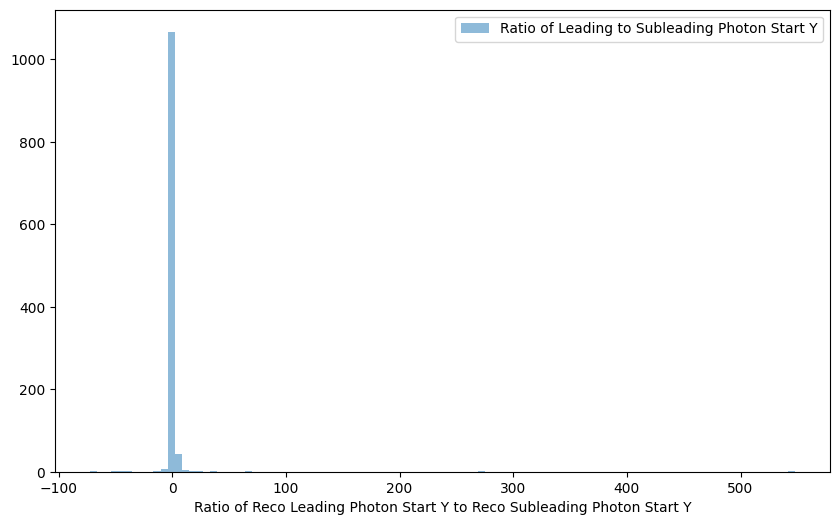

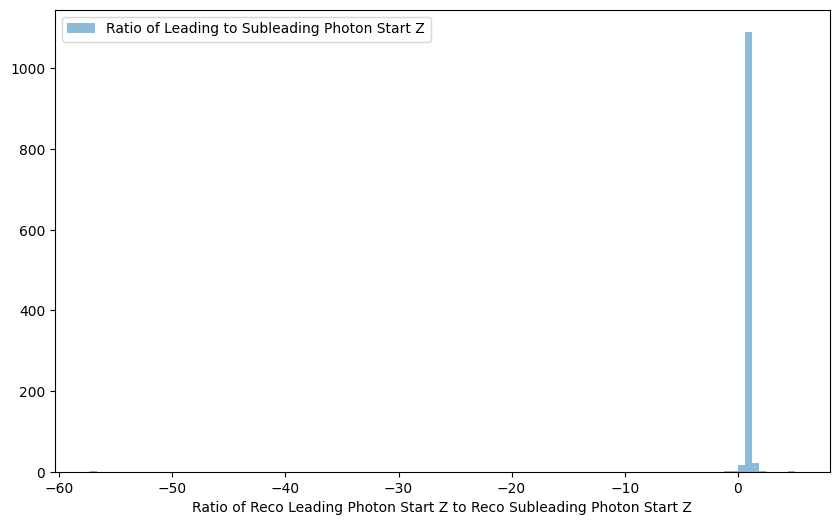

: 

In [ ]:
#BNB, input000.flat.root
#yy-shower reco selection 

#Importing relevant libraries
import numpy
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/All_BNB_ee_yy_ey_Showers_reco_selection_V2.root:events/BNB_simulation/yy_shower_interaction_reco"
)

#showing all TBranches
file.keys()

#Multiplicty variables of interest -------------------------------------------------------

#Extracting multiplicity variables from TBranches and combining them into a single dataframe
combinedmultiplicity = file.arrays(["true_photon_multiplicity", "true_muon_multiplicity","true_pion_multiplicity","true_proton_multiplicity","true_electron_multiplicity",],library="pd")
combinedmultiplicity

#Finding interactions that are correctly reconstructed as having 2 primary photons and no other primary particles
correctlyrecomultiplicity = combinedmultiplicity[(combinedmultiplicity["true_photon_multiplicity"] == 2) & (combinedmultiplicity["true_electron_multiplicity"] == 0) & (combinedmultiplicity["true_muon_multiplicity"] == 0) & (combinedmultiplicity["true_pion_multiplicity"] == 0) & (combinedmultiplicity["true_proton_multiplicity"] == 0)]
correctlyrecomultiplicity

#Finding interactions that are not correctly reconstructed as having 2 primary photons and no other primary particles
poorlyrecomultiplicity = combinedmultiplicity[~((combinedmultiplicity["true_photon_multiplicity"] == 2) & (combinedmultiplicity["true_electron_multiplicity"] == 0) & (combinedmultiplicity["true_muon_multiplicity"] == 0) & (combinedmultiplicity["true_pion_multiplicity"] == 0) & (combinedmultiplicity["true_proton_multiplicity"] == 0))]
poorlyrecomultiplicity

cols = [
    "true_photon_multiplicity",
    "true_muon_multiplicity",
    "true_pion_multiplicity",
    "true_proton_multiplicity",
    "true_electron_multiplicity",
]

# Group identical rows and count
group_counts = (
    poorlyrecomultiplicity.groupby(cols)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

# Print all groups
print(group_counts.to_string(index=False))

#Grouping all variables together into a single dataframe -------------------------------------------------------
Allinteractions = file.arrays(["true_photon_multiplicity", "true_muon_multiplicity","true_pion_multiplicity","true_proton_multiplicity","true_electron_multiplicity"
                               ,"reco_dpT","reco_flash_time","reco_leading_photon_axial_spread","reco_leading_photon_azimuthal_angle","reco_leading_photon_ke","reco_leading_photon_electron_softmax","reco_leading_photon_iou"
                               ,"reco_leading_photon_directional_spread","reco_leading_photon_photon_softmax","reco_leading_photon_primary_softmax","reco_leading_photon_polar_angle","reco_leading_photon_secondary_softmax"
                               ,"reco_leading_photon_start_dedx","reco_leading_photon_start_dir_x","reco_leading_photon_start_dir_y","reco_leading_photon_start_dir_z","reco_leading_photon_start_x","reco_leading_photon_start_y","reco_leading_photon_start_z"
                               ,"reco_leading_photon_vertex_distance","reco_subleading_primary_gOre_axial_spread","reco_subleading_primary_gOre_azimuthal_angle","reco_subleading_primary_gOre_ke","reco_subleading_primary_gOre_electron_softmax","reco_subleading_primary_gOre_iou"
                               ,"reco_subleading_primary_gOre_directional_spread","reco_subleading_primary_gOre_photon_softmax","reco_subleading_primary_gOre_primary_softmax","reco_subleading_primary_gOre_polar_angle","reco_subleading_primary_gOre_secondary_softmax"
                               ,"reco_subleading_primary_gOre_start_dedx","reco_subleading_primary_gOre_start_dir_x","reco_subleading_primary_gOre_start_dir_y","reco_subleading_primary_gOre_start_dir_z","reco_subleading_primary_gOre_start_x","reco_subleading_primary_gOre_start_y","reco_subleading_primary_gOre_start_z"
                               ,"reco_subleading_primary_gOre_vertex_distance"],library="pd")
Allinteractions

#Seperating correctly reconstructed interactions from poorly reconstructed interactions -------------------------------------------------------

#Grouping correctly reconstructed interactions as having 2 primary photons and no other primary particles together with their reco variables into a single dataframe
Correct_reco_interactions = Allinteractions[(Allinteractions["true_photon_multiplicity"] == 2) & (Allinteractions["true_electron_multiplicity"] == 0) & (Allinteractions["true_muon_multiplicity"] == 0) & (Allinteractions["true_pion_multiplicity"] == 0) & (Allinteractions["true_proton_multiplicity"] == 0)]
Correct_reco_interactions

#Grouping 2y1p true interactions together with their reco variables into a single dataframe
two_y_1_p_reco_interactions = Allinteractions[(Allinteractions["true_photon_multiplicity"] == 2) & (Allinteractions["true_electron_multiplicity"] == 0) & (Allinteractions["true_muon_multiplicity"] == 0) & (Allinteractions["true_pion_multiplicity"] == 0) & (Allinteractions["true_proton_multiplicity"] == 1)]
two_y_1_p_reco_interactions

#Grouping 2y1pi true interactions together with their reco variables into a single dataframe
two_y_1_pi_reco_interactions = Allinteractions[(Allinteractions["true_photon_multiplicity"] == 2) & (Allinteractions["true_electron_multiplicity"] == 0) & (Allinteractions["true_muon_multiplicity"] == 0) & (Allinteractions["true_pion_multiplicity"] == 1) & (Allinteractions["true_proton_multiplicity"] == 0)]
two_y_1_pi_reco_interactions

#Grouping 1y true interactions together with their reco variables into a single dataframe
one_y_reco_interactions = Allinteractions[(Allinteractions["true_photon_multiplicity"] == 1) & (Allinteractions["true_electron_multiplicity"] == 0) & (Allinteractions["true_muon_multiplicity"] == 0) & (Allinteractions["true_pion_multiplicity"] == 0) & (Allinteractions["true_proton_multiplicity"] == 0)]
one_y_reco_interactions

#Comparing the reco variable distributions of correctly reconstructed interactions with 2y1p, 2y1pi and 1y true interactions to identify potential variables that can be used to separate these interaction types from each other and from correctly reconstructed interactions -------------------------------------------------------

#Interaction-level variables of interest: reco dpT, reco flash time -------------------------------------------------------------------------------
#Plotting the distribution of reco dpT for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_dpT"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_dpT"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_dpT"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_dpT"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco dpT")
plt.ylabel("Counts")
plt.legend()
plt.show()

#PLotting the distribution of reco flash time for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_flash_time"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_flash_time"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_flash_time"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_flash_time"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Flash Time")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Leading photon variables of interest: -----------------------------------------------------
#Plotting the distribution of reco leading photon ke for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_ke"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_ke"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_ke"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_ke"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon KE")       
plt.ylabel("Counts")
plt.legend()
plt.show() 

#Plotting the distribution of reco leading photon start dedx for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_start_dedx"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_start_dedx"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_start_dedx"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_start_dedx"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Start dE/dx")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon axial spread for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_axial_spread"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_axial_spread"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_axial_spread"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_axial_spread"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Axial Spread")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon directional spread for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_directional_spread"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_directional_spread"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_directional_spread"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_directional_spread"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Directional Spread")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon azimuthal angle for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_azimuthal_angle"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_azimuthal_angle"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_azimuthal_angle"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_azimuthal_angle"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Azimuthal Angle")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon polar angle for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_polar_angle"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_polar_angle"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_polar_angle"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_polar_angle"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Polar Angle")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon iou for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_iou"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_iou"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_iou"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_iou"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon IOU")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon vertex distance for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_vertex_distance"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_leading_photon_vertex_distance"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_leading_photon_vertex_distance"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_leading_photon_vertex_distance"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Vertex Distance")
plt.ylabel("Counts")
plt.legend()
plt.show()

#subLeading photon variables of interest: -----------------------------------------------------
#Plotting the distribution of reco subleading photon ke for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon KE")       
plt.ylabel("Counts")
plt.legend()
plt.show() 

#Plotting the distribution of reco subleading photon start dedx for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_start_dedx"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_start_dedx"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_start_dedx"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_start_dedx"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Start dE/dx")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon axial spread for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_axial_spread"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_axial_spread"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_axial_spread"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_axial_spread"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Axial Spread")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon directional spread for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_directional_spread"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_directional_spread"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_directional_spread"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_directional_spread"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Directional Spread")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon azimuthal angle for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_azimuthal_angle"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_azimuthal_angle"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_azimuthal_angle"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_azimuthal_angle"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Azimuthal Angle")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon polar angle for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_polar_angle"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_polar_angle"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_polar_angle"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_polar_angle"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Polar Angle")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon iou for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_iou"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_iou"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_iou"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_iou"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon IOU")
plt.ylabel("Counts")
plt.legend()
plt.show()

#Plotting the distribution of reco subleading photon vertex distance for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_vertex_distance"], bins=100, alpha=0.5, label="Correctly Reconstructed")
plt.hist(two_y_1_p_reco_interactions["reco_subleading_primary_gOre_vertex_distance"], bins=100, alpha=0.5, label="2Y1P")
plt.hist(two_y_1_pi_reco_interactions["reco_subleading_primary_gOre_vertex_distance"], bins=100, alpha=0.5, label="2Y1PI")
plt.hist(one_y_reco_interactions["reco_subleading_primary_gOre_vertex_distance"], bins=100, alpha=0.5, label="1Y")
plt.xlabel("Reco Subleading Photon Vertex Distance")
plt.ylabel("Counts")
plt.legend()
plt.show()


#comparing photon variables of interest: -----------------------------------------------------
#Plotting the distribution of reco leading photon start dedx vs reco leading photon ke for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.scatter(Correct_reco_interactions["reco_leading_photon_ke"], Correct_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="Correctly Reconstructed")
plt.scatter(two_y_1_p_reco_interactions["reco_leading_photon_ke"], two_y_1_p_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="2Y1P")
plt.scatter(two_y_1_pi_reco_interactions["reco_leading_photon_ke"], two_y_1_pi_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="2Y1PI")
plt.scatter(one_y_reco_interactions["reco_leading_photon_ke"], one_y_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon KE")
plt.ylabel("Reco Leading Photon Start dE/dx")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon startdedx vs reco leading photon vertex distance for correctly reconstructed interactions, 2y1p, 2y1pi and 1y true interactions
plt.figure(figsize=(10, 6))
plt.scatter(Correct_reco_interactions["reco_leading_photon_vertex_distance"], Correct_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="Correctly Reconstructed")
plt.scatter(two_y_1_p_reco_interactions["reco_leading_photon_vertex_distance"], two_y_1_p_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="2Y1P")
plt.scatter(two_y_1_pi_reco_interactions["reco_leading_photon_vertex_distance"], two_y_1_pi_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="2Y1PI")
plt.scatter(one_y_reco_interactions["reco_leading_photon_vertex_distance"], one_y_reco_interactions["reco_leading_photon_start_dedx"], alpha=0.5, label="1Y")
plt.xlabel("Reco Leading Photon Vertex Distance")
plt.ylabel("Reco Leading Photon Start dE/dx")
plt.legend()
plt.show()

#Plotting the distribution of reco leading photon ke and reco subeading photon ke for correctly reconstructed interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_ke"], bins=100, alpha=0.5, label="Leading photon ke")
plt.hist(Correct_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="Subleading photon ke")
plt.xlabel("Reco Leading Photon KE / Reco Subleading Photon KE")
plt.legend()

#Plotting the ratio of reco leading photon ke and reco subeading photon ke for correctly reconstructed interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_ke"] / Correct_reco_interactions["reco_subleading_primary_gOre_ke"], bins=100, alpha=0.5, label="Ratio of Leading to Subleading Photon KE")
plt.xlabel("Ratio of Reco Leading Photon KE to Reco Subleading Photon KE")
plt.legend()
plt.show()

#Plotting ratio of reco leading photon start x and reco subleading photon start x for correctly reconstructed interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_start_x"] / Correct_reco_interactions["reco_subleading_primary_gOre_start_x"], bins=100, alpha=0.5, label="Ratio of Leading to Subleading Photon Start X")
plt.xlabel("Ratio of Reco Leading Photon Start X to Reco Subleading Photon Start X")
plt.legend()

#Plotting ratio of reco leading photon start y and reco subleading photon start y for correctly reconstructed interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_start_y"] / Correct_reco_interactions["reco_subleading_primary_gOre_start_y"], bins=100, alpha=0.5, label="Ratio of Leading to Subleading Photon Start Y")
plt.xlabel("Ratio of Reco Leading Photon Start Y to Reco Subleading Photon Start Y")
plt.legend()

#Plotting ratio of reco leading photon start z and reco subleading photon start z for correctly reconstructed interactions
plt.figure(figsize=(10, 6))
plt.hist(Correct_reco_interactions["reco_leading_photon_start_z"] / Correct_reco_interactions["reco_subleading_primary_gOre_start_z"], bins=100, alpha=0.5, label="Ratio of Leading to Subleading Photon Start Z")
plt.xlabel("Ratio of Reco Leading Photon Start Z to Reco Subleading Photon Start Z")
plt.legend()



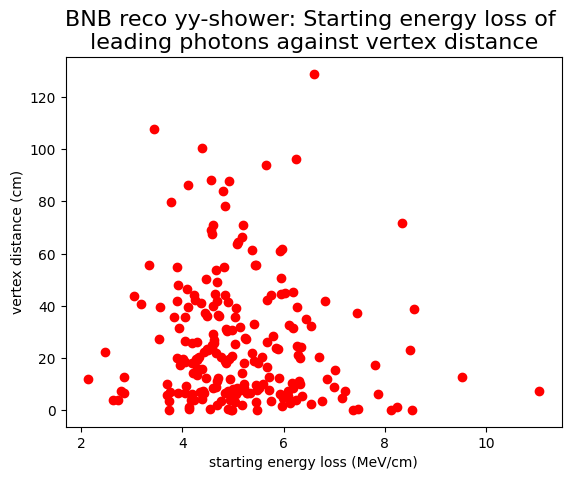

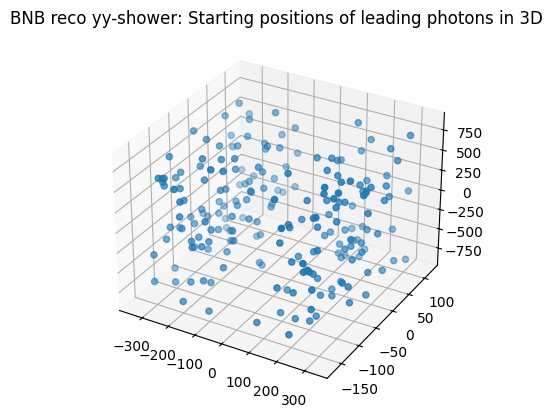

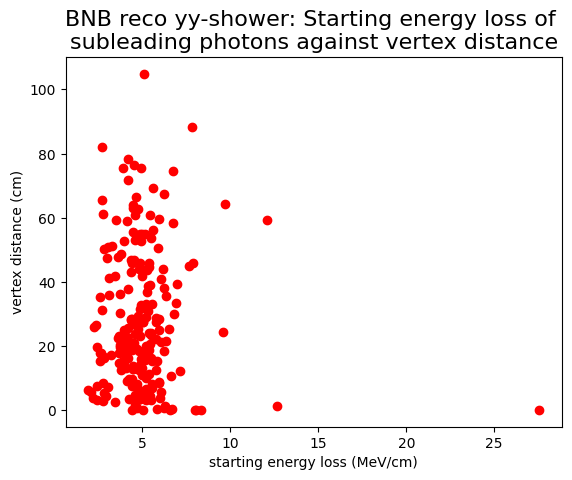

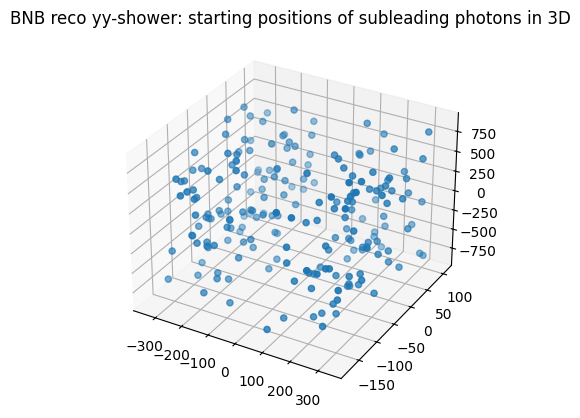

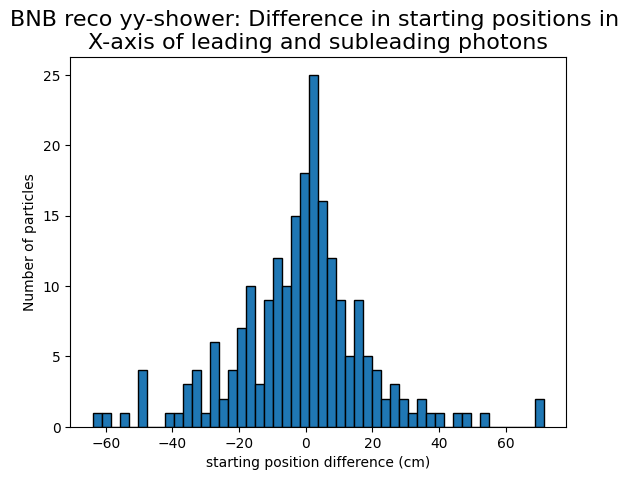

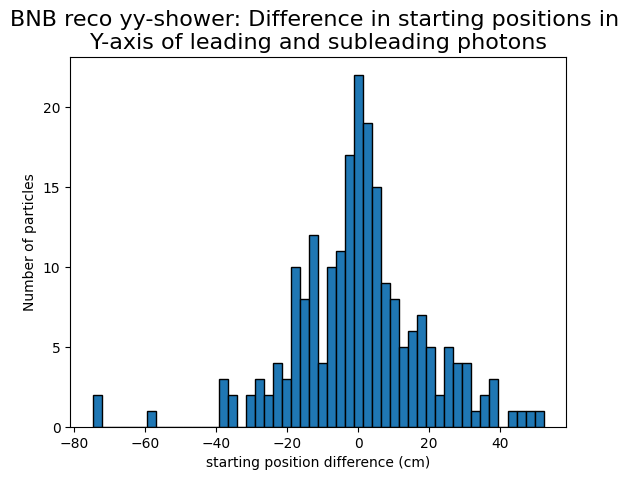

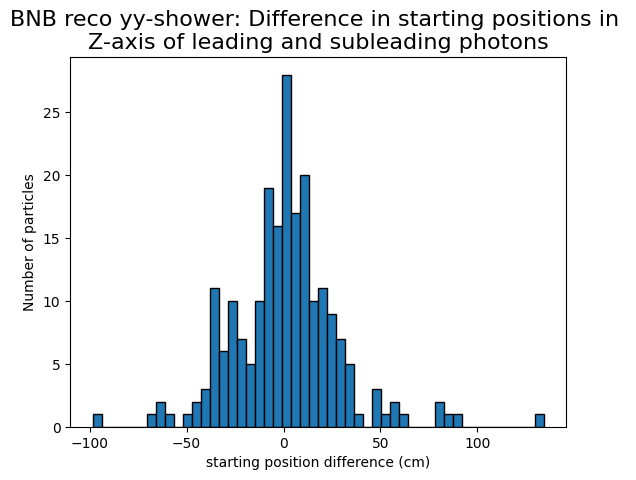

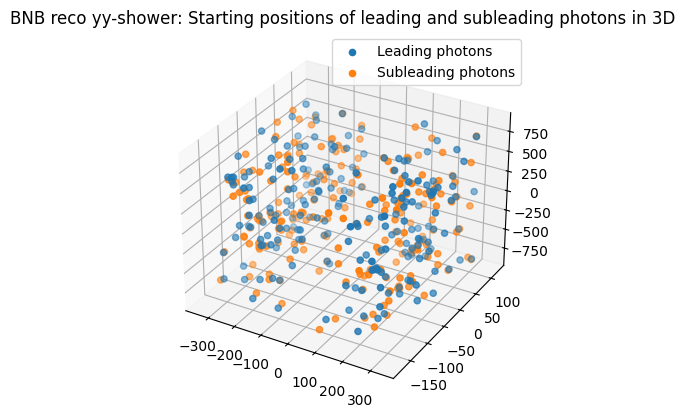

In [ ]:
#BNB, input000.flat.root
#yy-shower reco selection 

#Importing relevant libraries
import numpy
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_Shower_Selection_flashcut/All_BNB_ee_yy_ey_Showers_reco_selection_V2.root:events/BNB_simulation_0/yy_shower_reco_particle"
)

#showing all TBranches
file.keys()

#Leading Photon shower particle plots
# --------------------------------------------------------------------------------

#Extracting vertex distance and starting energy loss from TBranches
vertexdist = file["reco_leading_photon_vertex_distance"].array(library="np")
vertexdist
startdedx = file["reco_leading_photon_start_dedx"].array(library="np")
startdedx
combined = file.arrays(["reco_leading_photon_vertex_distance", "reco_leading_photon_start_dedx"],library="pd")
combined

#Plotting starting energy loss against vertex distance
plt.plot([startdedx],[vertexdist],'ro')
plt.xlabel("starting energy loss (MeV/cm)")
plt.ylabel("vertex distance (cm)")
plt.title("BNB reco yy-shower: Starting energy loss of \nleading photons against vertex distance", fontsize=16)
plt.show()

#Extracting vertex distance and starting energy loss from TBranches
startx = file["reco_leading_photon_start_x"].array(library="np")
starty = file["reco_leading_photon_start_y"].array(library="np")
startz = file["reco_leading_photon_start_z"].array(library="np")

#Plotting starting positions of leading photons in 3D

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(startx, starty, startz, 'green')
ax.set_title('BNB reco yy-shower: Starting positions of leading photons in 3D')
plt.show()

#Subleading Photon shower particle plots
# --------------------------------------------------------------------------------

#Extracting vertex distance and starting energy loss from TBranches
subvertexdist = file["reco_subleading_primary_gOre_vertex_distance"].array(library="np")
subvertexdist
substartdedx = file["reco_subleading_primary_gOre_start_dedx"].array(library="np")
substartdedx

#Plotting starting energy loss against vertex distance
plt.plot([substartdedx],[subvertexdist],'ro')
plt.xlabel("starting energy loss (MeV/cm)")
plt.ylabel("vertex distance (cm)")
plt.title("BNB reco yy-shower: Starting energy loss of \nsubleading photons against vertex distance", fontsize=16)
plt.show()

#Extracting vertex distance and starting energy loss from TBranches
substartx = file["reco_subleading_primary_gOre_start_x"].array(library="np")
substarty = file["reco_subleading_primary_gOre_start_y"].array(library="np")
substartz = file["reco_subleading_primary_gOre_start_z"].array(library="np")

#plotting starting positions of subleading photons in 3D
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(substartx, substarty, substartz, 'red')
ax.set_title('BNB reco yy-shower: starting positions of subleading photons in 3D')
plt.show()

#Leading and Subleading Photon shower particle plots

#Extracting difference value of starting positions of leading and subleading photons from TBranches
diffstartx = startx - substartx
diffstarty = starty - substarty
diffstartz = startz - substartz
#Plotting difference in starting positions of leading and subleading photons seperately
plt.hist(diffstartx,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("BNB reco yy-shower: Difference in starting positions in \nX-axis of leading and subleading photons", fontsize=16)
plt.show()

plt.hist(diffstarty,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("BNB reco yy-shower: Difference in starting positions in \nY-axis of leading and subleading photons", fontsize=16)
plt.show()

plt.hist(diffstartz,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("BNB reco yy-shower: Difference in starting positions in \nZ-axis of leading and subleading photons", fontsize=16)
plt.show()

#plotting starting positions of leading and subleading photons in 3D
startlead = [startx, starty, startz]
substart = [substartx, substarty, substartz]
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(startlead[0], startlead[1], startlead[2], 'green', label='Leading photons')
ax.scatter(substart[0], substart[1], substart[2], 'red', label='Subleading photons')
ax.set_title('BNB reco yy-shower: Starting positions of leading and subleading photons in 3D')
plt.legend()
plt.show()



<h2 style="font-size: 40px;">2. NuMI</h2>

<h2 style="font-size: 24px;">2.1. yy-shower reco particle selection</h2>

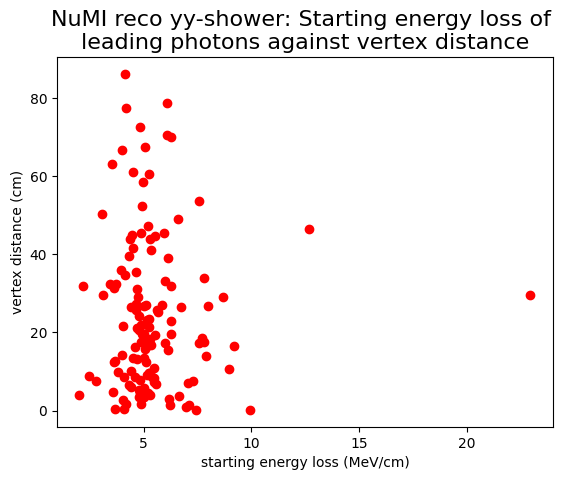

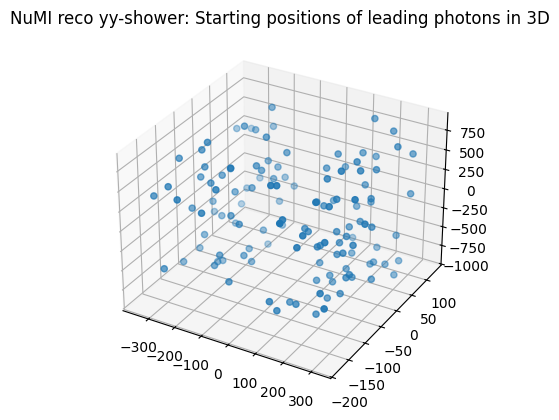

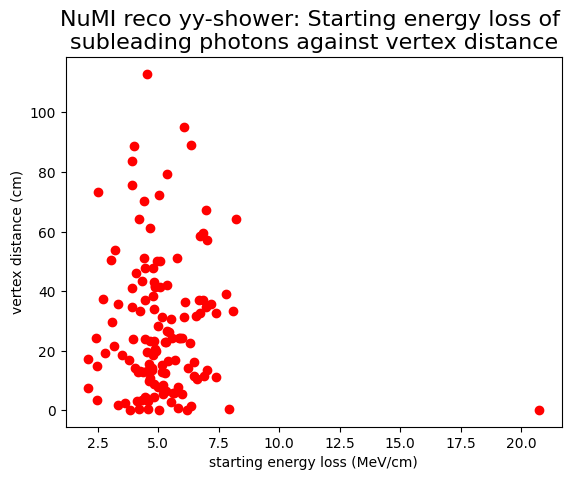

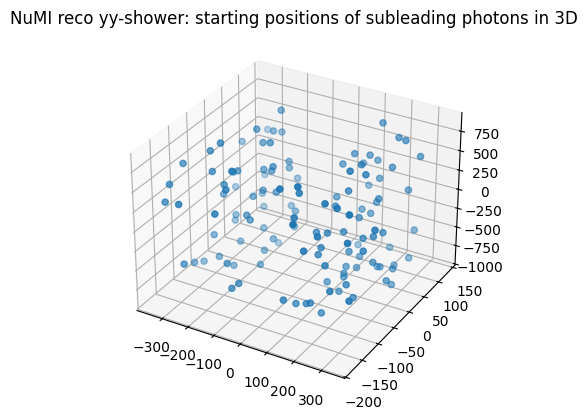

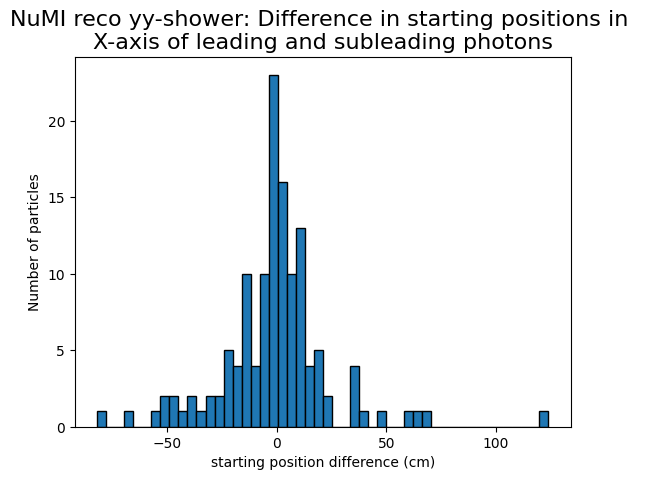

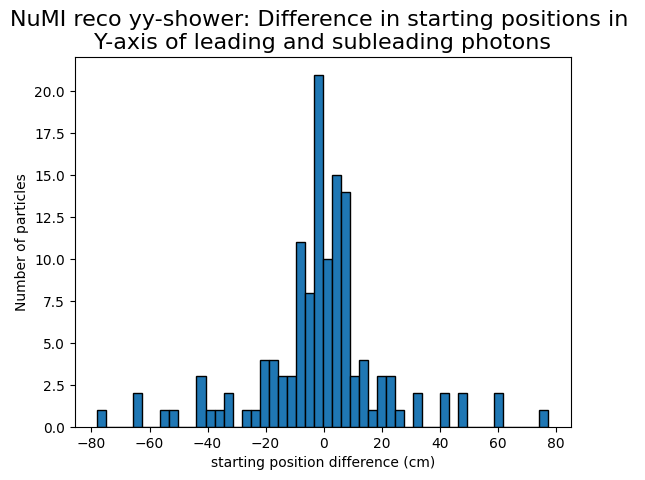

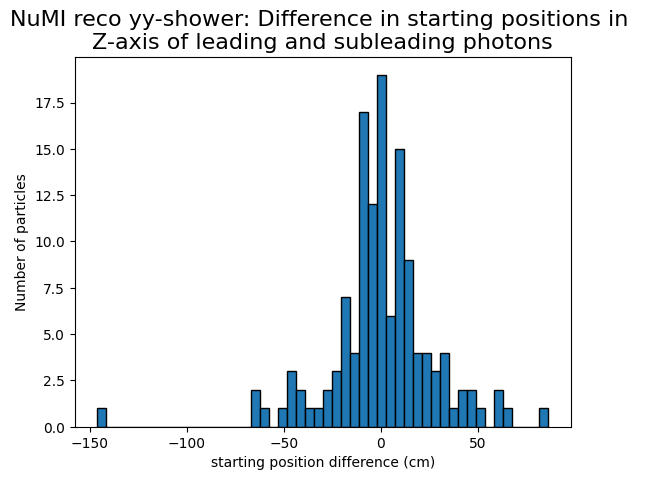

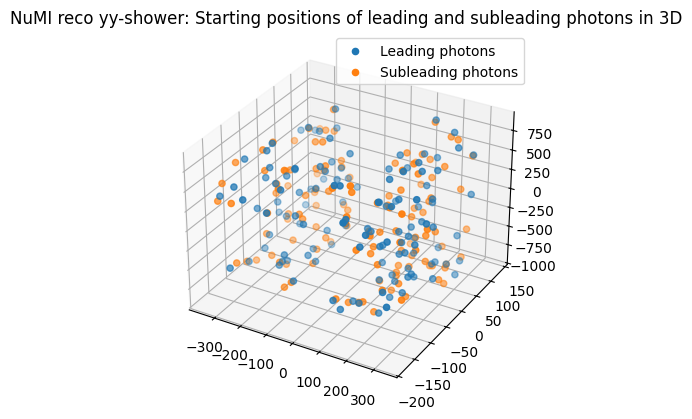

In [1]:
#NuMI, NuMI_CV_flat_cafs_2_00 
#yy-shower reco selection 

#Importing relevant libraries
import numpy
import uproot
import pandas
import hist
import matplotlib.pyplot as plt

#enable this to see all outputs in a cell
#from IPython.core.interactiveshell import InteractiveShell
#InteractiveShell.ast_node_interactivity = "all"

#Opening the relevant ROOT file and tree
file = uproot.open(
    "e:/FYP/medulla_outputs/2_shower_event_preselection_and_selection_reco.root:events/NuMI_simulation_0/yy_shower_reco_particle"
)

#showing all TBranches
file.keys()

#Leading Photon shower particle plots
# --------------------------------------------------------------------------------

#Extracting vertex distance and starting energy loss from TBranches
vertexdist = file["reco_leading_photon_vertex_distance"].array(library="np")
vertexdist
startdedx = file["reco_leading_photon_start_dedx"].array(library="np")
startdedx
combined = file.arrays(["reco_leading_photon_vertex_distance", "reco_leading_photon_start_dedx"],library="pd")
combined

#Plotting starting energy loss against vertex distance
plt.plot([startdedx],[vertexdist],'ro')
plt.xlabel("starting energy loss (MeV/cm)")
plt.ylabel("vertex distance (cm)")
plt.title("NuMI reco yy-shower: Starting energy loss of \nleading photons against vertex distance", fontsize=16)
plt.show()

#Extracting vertex distance and starting energy loss from TBranches
startx = file["reco_leading_photon_start_x"].array(library="np")
starty = file["reco_leading_photon_start_y"].array(library="np")
startz = file["reco_leading_photon_start_z"].array(library="np")

#Plotting starting positions of leading photons in 3D

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(startx, starty, startz, 'green')
ax.set_title('NuMI reco yy-shower: Starting positions of leading photons in 3D')
plt.show()

#Subleading Photon shower particle plots
# --------------------------------------------------------------------------------

#Extracting vertex distance and starting energy loss from TBranches
subvertexdist = file["reco_subleading_primary_gOre_vertex_distance"].array(library="np")
subvertexdist
substartdedx = file["reco_subleading_primary_gOre_start_dedx"].array(library="np")
substartdedx

#Plotting starting energy loss against vertex distance
plt.plot([substartdedx],[subvertexdist],'ro')
plt.xlabel("starting energy loss (MeV/cm)")
plt.ylabel("vertex distance (cm)")
plt.title("NuMI reco yy-shower: Starting energy loss of \nsubleading photons against vertex distance", fontsize=16)
plt.show()

#Extracting vertex distance and starting energy loss from TBranches
substartx = file["reco_subleading_primary_gOre_start_x"].array(library="np")
substarty = file["reco_subleading_primary_gOre_start_y"].array(library="np")
substartz = file["reco_subleading_primary_gOre_start_z"].array(library="np")

#plotting starting positions of subleading photons in 3D
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(substartx, substarty, substartz, 'red')
ax.set_title('NuMI reco yy-shower: starting positions of subleading photons in 3D')
plt.show()

#Leading and Subleading Photon shower particle plots

#Extracting difference value of starting positions of leading and subleading photons from TBranches
diffstartx = startx - substartx
diffstarty = starty - substarty
diffstartz = startz - substartz
#Plotting difference in starting positions of leading and subleading photons seperately
plt.hist(diffstartx,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("NuMI reco yy-shower: Difference in starting positions in \nX-axis of leading and subleading photons", fontsize=16)
plt.show()

plt.hist(diffstarty,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("NuMI reco yy-shower: Difference in starting positions in \nY-axis of leading and subleading photons", fontsize=16)
plt.show()

plt.hist(diffstartz,bins=50,edgecolor='black')
plt.xlabel("starting position difference (cm)")
plt.ylabel("Number of particles")
plt.title("NuMI reco yy-shower: Difference in starting positions in \nZ-axis of leading and subleading photons", fontsize=16)
plt.show()

#plotting starting positions of leading and subleading photons in 3D
startlead = [startx, starty, startz]
substart = [substartx, substarty, substartz]
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(startlead[0], startlead[1], startlead[2], 'green', label='Leading photons')
ax.scatter(substart[0], substart[1], substart[2], 'red', label='Subleading photons')
ax.set_title('NuMI reco yy-shower: Starting positions of leading and subleading photons in 3D')
plt.legend()
plt.show()


